# Karachi Traffic Congestion - Exploratory Data Analysis (Week 3)

This notebook explores patterns in the traffic congestion dataset across routes, time of day, day of week, and weather.

**Data source note:** This currently uses synthetic data generated to simulate realistic Karachi traffic patterns, while real hourly data accumulates via the automated collection script. Check the `is_synthetic` column before drawing real-world conclusions.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the feature-engineered dataset (output of feature_engineering.py)
df = pd.read_csv('../data/processed/traffic_data_features.csv', parse_dates=['timestamp'])

print(f"Loaded {len(df)} rows")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Routes: {df['route_id'].nunique()}")
df.head()

Loaded 43440 rows
Date range: 2026-02-01 00:00:00 to 2026-07-31 23:00:00
Routes: 10


,timestamp,route_id,route_name,corridor,travel_time_with_traffic_sec,free_flow_time_sec,congestion_index,temperature_c,precipitation_mm,weather_code,is_synthetic,hour_of_day,day_of_week,is_weekend,is_friday,congestion_1hr_ago,congestion_3hr_ago
0,2026-02-01 00:00:00,1,Regal Chowk to Tower,M.A. Jinnah Rd / I.I. Chundrigar Rd,397.0,384.0,1.034,25.2,0.0,1,True,0,6,True,False,NaN,NaN
1,2026-02-01 01:00:00,1,Regal Chowk to Tower,M.A. Jinnah Rd / I.I. Chundrigar Rd,422.0,384.0,1.102,23.7,0.0,1,True,1,6,True,False,1.034,NaN
2,2026-02-01 02:00:00,1,Regal Chowk to Tower,M.A. Jinnah Rd / I.I. Chundrigar Rd,395.0,384.0,1.031,23.4,0.0,1,True,2,6,True,False,1.102,NaN
3,2026-02-01 03:00:00,1,Regal Chowk to Tower,M.A. Jinnah Rd / I.I. Chundrigar Rd,429.0,384.0,1.117,23.4,0.0,1,True,3,6,True,False,1.031,1.034
4,2026-02-01 04:00:00,1,Regal Chowk to Tower,M.A. Jinnah Rd / I.I. Chundrigar Rd,443.0,384.0,1.156,27.9,0.0,1,True,4,6,True,False,1.117,1.102


## 1. Basic overview

Before looking for patterns, let's confirm the data looks healthy - correct types, reasonable ranges, no surprises.

In [2]:
df.info()
print()
df[['congestion_index', 'temperature_c', 'precipitation_mm']].describe()

<class 'pandas.DataFrame'>
RangeIndex: 43440 entries, 0 to 43439
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   timestamp                     43440 non-null  datetime64[us]
 1   route_id                      43440 non-null  int64         
 2   route_name                    43440 non-null  str           
 3   corridor                      43440 non-null  str           
 4   travel_time_with_traffic_sec  43440 non-null  float64       
 5   free_flow_time_sec            43440 non-null  float64       
 6   congestion_index              43440 non-null  float64       
 7   temperature_c                 43440 non-null  float64       
 8   precipitation_mm              43440 non-null  float64       
 9   weather_code                  43440 non-null  int64         
 10  is_synthetic                  43440 non-null  bool          
 11  hour_of_day                   43440 non

,congestion_index,temperature_c,precipitation_mm
count,43440.000000,43440.000000,43440.000000
mean,1.206787,30.169245,0.324632
std,0.227984,4.098485,1.625415
min,1.000000,15.300000,0.000000
25%,1.049000,27.400000,0.000000
50%,1.111000,30.600000,0.000000
75%,1.269000,33.200000,0.000000
max,2.854000,41.800000,24.500000


## 2. Congestion by hour of day

This is the most fundamental pattern in traffic data (our literature review point 1 - daily seasonality). We expect to see peaks around 8-10am and 5-8pm.

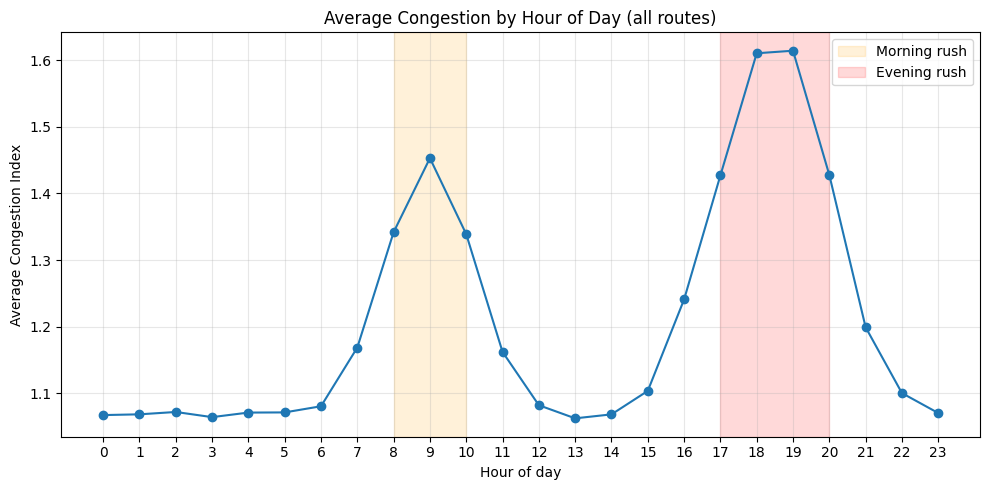

In [3]:
hourly_avg = df.groupby('hour_of_day')['congestion_index'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.axvspan(8, 10, color='orange', alpha=0.15, label='Morning rush')
plt.axvspan(17, 20, color='red', alpha=0.15, label='Evening rush')
plt.xlabel('Hour of day')
plt.ylabel('Average Congestion Index')
plt.title('Average Congestion by Hour of Day (all routes)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/eda_hourly_pattern.png', dpi=100)
plt.show()

## 3. Weekday vs Weekend comparison

We expect weekends to show much lower and flatter congestion, since office/school commute traffic disappears.

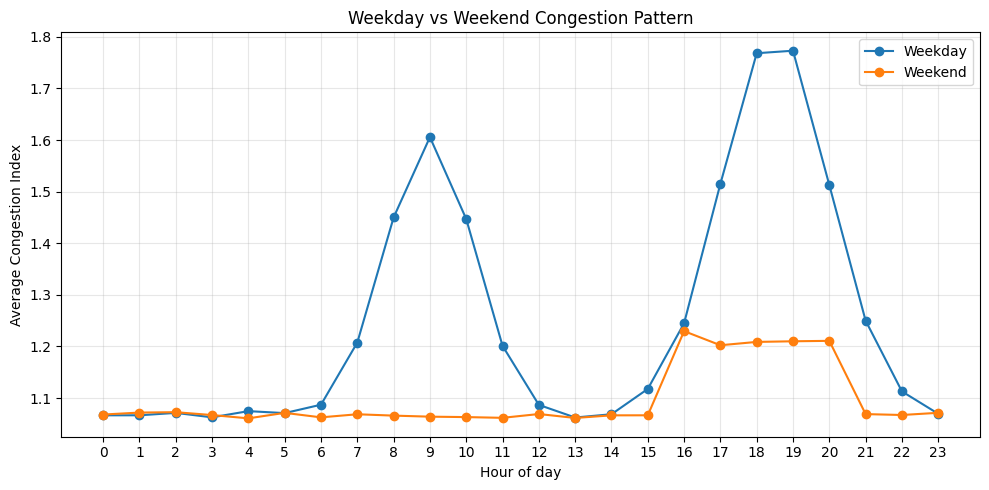

In [4]:
df['day_type'] = df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})
hourly_by_daytype = df.groupby(['day_type', 'hour_of_day'])['congestion_index'].mean().unstack(level=0)

plt.figure(figsize=(10, 5))
plt.plot(hourly_by_daytype.index, hourly_by_daytype['Weekday'], marker='o', label='Weekday')
plt.plot(hourly_by_daytype.index, hourly_by_daytype['Weekend'], marker='o', label='Weekend')
plt.xlabel('Hour of day')
plt.ylabel('Average Congestion Index')
plt.title('Weekday vs Weekend Congestion Pattern')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/eda_weekday_vs_weekend.png', dpi=100)
plt.show()

## 4. Congestion by day of week

Checking if any single day (e.g. Friday, due to Jummah prayers) shows a distinct pattern from the rest.

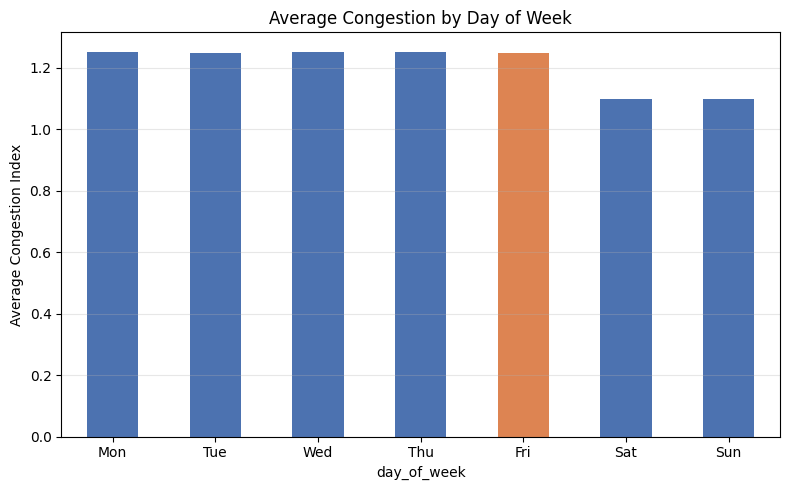

In [5]:
day_names = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
daily_avg = df.groupby('day_of_week')['congestion_index'].mean()
daily_avg.index = daily_avg.index.map(day_names)

plt.figure(figsize=(8, 5))
daily_avg.plot(kind='bar', color=['#4C72B0']*4 + ['#DD8452'] + ['#4C72B0']*2)
plt.ylabel('Average Congestion Index')
plt.title('Average Congestion by Day of Week')
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../reports/eda_day_of_week.png', dpi=100)
plt.show()

## 5. Congestion by route / corridor

Which routes are typically the most congested? This helps prioritize which routes might need the most careful modeling later.

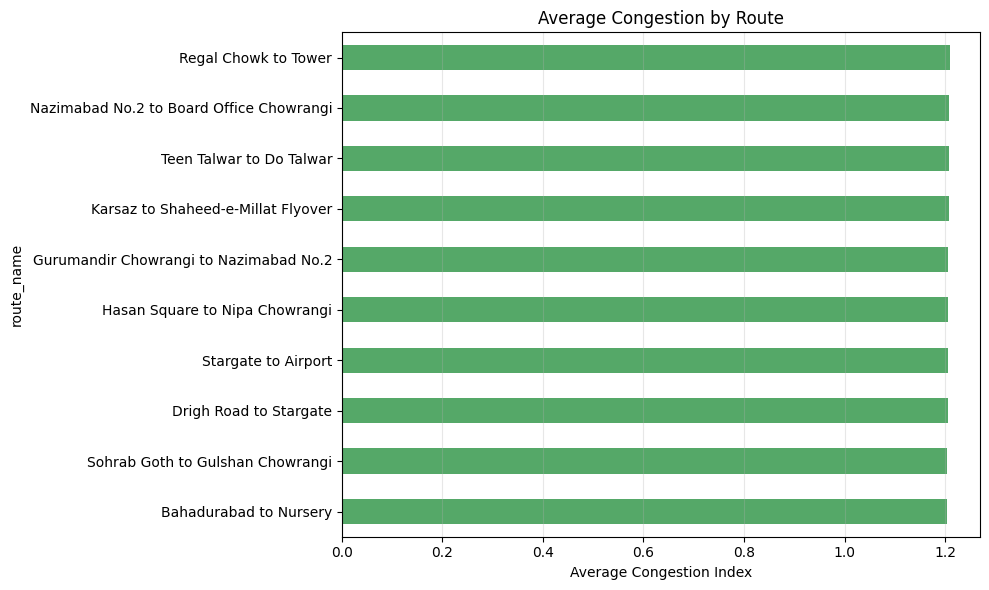

In [6]:
route_avg = df.groupby('route_name')['congestion_index'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
route_avg.plot(kind='barh', color='#55A868')
plt.xlabel('Average Congestion Index')
plt.title('Average Congestion by Route')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../reports/eda_by_route.png', dpi=100)
plt.show()

## 6. Weather effect on congestion

Testing our literature review point 3: does rain actually correlate with higher congestion in this data?

Average congestion_index:
rain_flag
Dry hours      1.202
Rainy hours    1.274
Name: congestion_index, dtype: float64


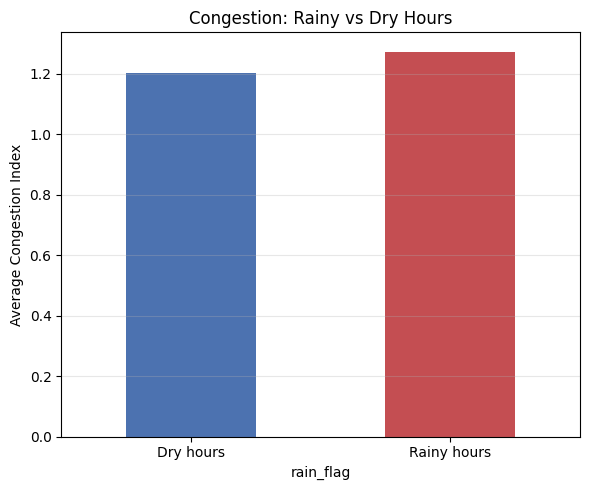

In [7]:
df['rain_flag'] = df['precipitation_mm'] > 0.5

rain_comparison = df.groupby('rain_flag')['congestion_index'].mean()
rain_comparison.index = rain_comparison.index.map({True: 'Rainy hours', False: 'Dry hours'})

print("Average congestion_index:")
print(rain_comparison.round(3))

plt.figure(figsize=(6, 5))
rain_comparison.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.ylabel('Average Congestion Index')
plt.title('Congestion: Rainy vs Dry Hours')
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../reports/eda_weather_effect.png', dpi=100)
plt.show()

## 7. One week close-up for a single route

Zooming into a single route over 7 days lets us see the daily rush-hour cycle repeat, which is exactly the pattern Prophet/ARIMA will need to learn in Week 4-5.

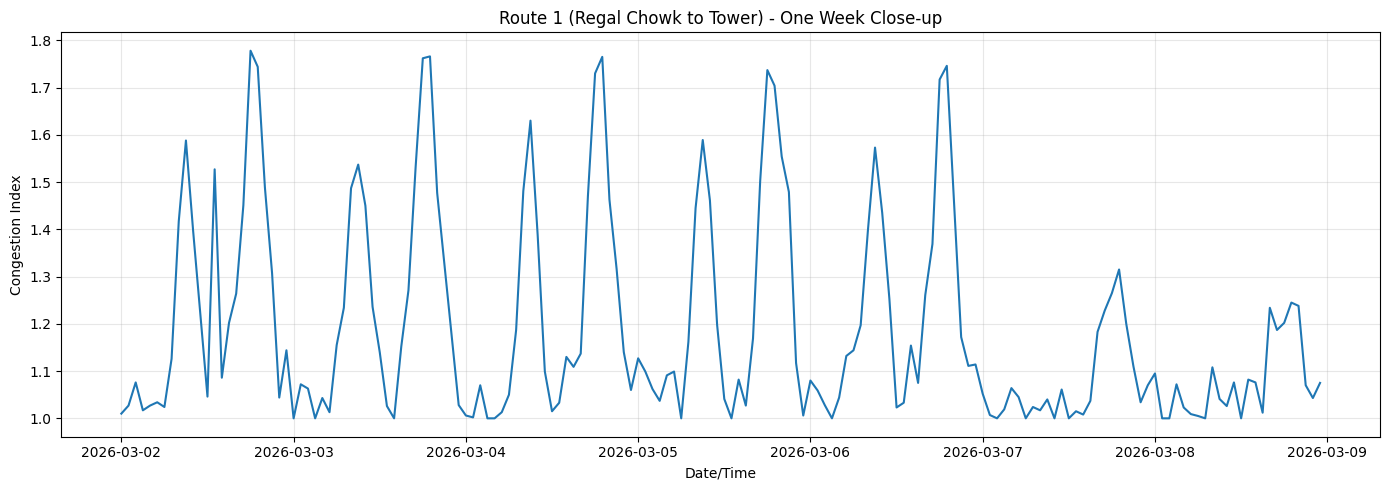

In [8]:
route_1 = df[df['route_id'] == 1].sort_values('timestamp')
one_week = route_1[(route_1['timestamp'] >= '2026-03-02') & (route_1['timestamp'] < '2026-03-09')]

plt.figure(figsize=(14, 5))
plt.plot(one_week['timestamp'], one_week['congestion_index'])
plt.xlabel('Date/Time')
plt.ylabel('Congestion Index')
plt.title(f"Route 1 ({route_1['route_name'].iloc[0]}) - One Week Close-up")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/eda_one_week_closeup.png', dpi=100)
plt.show()

## 8. Lag feature correlation check

Do the lag features we engineered (congestion 1hr/3hr ago) actually correlate with the current congestion_index? If yes, this confirms autocorrelation exists (literature review point 2) and that ARIMA-style models should work well.

                    congestion_index  congestion_1hr_ago  congestion_3hr_ago
congestion_index               1.000               0.698               0.009
congestion_1hr_ago             0.698               1.000               0.352
congestion_3hr_ago             0.009               0.352               1.000


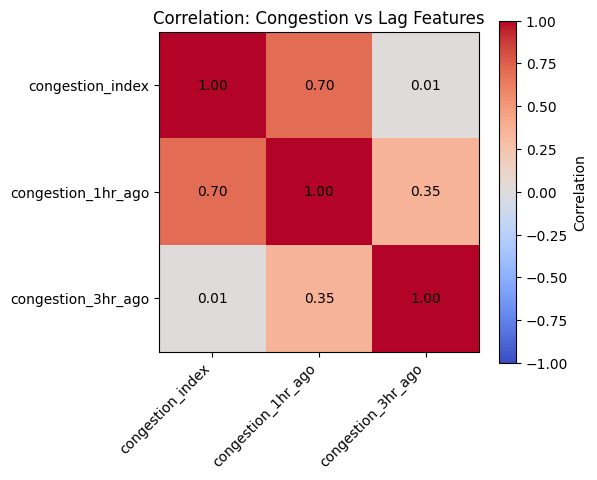

In [9]:
correlation_cols = ['congestion_index', 'congestion_1hr_ago', 'congestion_3hr_ago']
corr_matrix = df[correlation_cols].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation_cols)), correlation_cols, rotation=45, ha='right')
plt.yticks(range(len(correlation_cols)), correlation_cols)
for i in range(len(correlation_cols)):
    for j in range(len(correlation_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}", ha='center', va='center')
plt.title('Correlation: Congestion vs Lag Features')
plt.tight_layout()
plt.savefig('../reports/eda_lag_correlation.png', dpi=100)
plt.show()

## Summary of findings

*(Fill this in after reviewing the charts above - a few sentences per point is enough for your data quality report deliverable)*

1. **Daily pattern:** ...
2. **Weekday vs weekend:** ...
3. **Day of week (Friday effect):** ...
4. **Most/least congested routes:** ...
5. **Weather effect:** ...
6. **Autocorrelation (lag features):** ...

These findings directly inform Week 4-5 modeling choices - e.g. strong lag correlation supports using ARIMA, while clear daily/weekly seasonality supports Prophet's seasonality components.